# Project B — Teachable Machine
## Task B3: Pose Model — Posture Classifier (bending / lying / sitting / standing)

**Objective:** Inspect the exported Teachable Machine pose model in Python and explain how it works. Live webcam classification runs in the browser (`pose/index.html`).

**Why the browser?** A Teachable Machine **Pose** project can only be exported as **TensorFlow.js** (`model.json` + `weights.bin`). Its input is not an image or 17 keypoints — it is the raw 14,739-value output of the PoseNet model that runs inside the Teachable Machine JS library. That PoseNet step is only available in JavaScript, so live prediction is done in `pose/index.html`.

### Step 1 — Imports
`pip install tensorflow tf_keras numpy matplotlib`

In [1]:
import json
import numpy as np
import tf_keras as keras
import matplotlib.pyplot as plt

### Step 2 — Read metadata (class names + PoseNet settings)

In [2]:
meta = json.load(open("models/pose/metadata.json"))
labels = meta["labels"]
print("Classes :", labels)
print("PoseNet :", meta["modelSettings"]["posenet"])
print("Package :", meta["packageName"], meta["packageVersion"])

Classes : ['bending', 'lying', 'sitting', 'standing']
PoseNet : {'architecture': 'MobileNetV1', 'outputStride': 16, 'inputResolution': 257, 'multiplier': 0.75}
Package : @teachablemachine/pose 0.8.6


### Step 3 — Rebuild the classification head in Keras
`model.json` describes: Dense(100, relu) → Dropout(0.5) → Dense(4, softmax, no bias), input size 14,739.
`weights.bin` holds the raw float32 weights. We load them by hand into an identical Keras model.

In [3]:
manifest = json.load(open("models/pose/model.json"))["weightsManifest"][0]["weights"]
raw = np.fromfile("models/pose/weights.bin", dtype="float32")

arrays, pos = {}, 0
for w in manifest:
    n = int(np.prod(w["shape"]))
    arrays[w["name"]] = raw[pos:pos + n].reshape(w["shape"])
    pos += n
    print(w["name"], w["shape"])

pose_model = keras.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=(14739,), name="dense_Dense1"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(4, activation="softmax", use_bias=False, name="dense_Dense2"),
])
pose_model.get_layer("dense_Dense1").set_weights([arrays["dense_Dense1/kernel"], arrays["dense_Dense1/bias"]])
pose_model.get_layer("dense_Dense2").set_weights([arrays["dense_Dense2/kernel"]])

dense_Dense1/kernel [14739, 100]
dense_Dense1/bias [100]
dense_Dense2/kernel [100, 4]



### Step 4 — Model introspection (Task B4.4)

In [4]:
pose_model.summary()
print("Input shape :", pose_model.input_shape)
print("Output shape:", pose_model.output_shape)
print("Layers      :", len(pose_model.layers))
print("Total params:", pose_model.count_params())
print("Trainable   :", sum(int(np.prod(w.shape)) for w in pose_model.trainable_weights))

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_Dense1 (Dense)        (None, 100)               1474000   
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                                 
 dense_Dense2 (Dense)        (None, 4)                 400       
                                                                 
Total params: 1474400 (5.62 MB)
Trainable params: 1474400 (5.62 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Input shape : (None, 14739)
Output shape: (None, 4)
Layers      : 3
Total params: 1474400
Trainable   : 1474400


**Observation:** All ~1.47M parameters belong to the head we trained. PoseNet itself (MobileNetV1) is frozen and runs separately in the browser.

### Step 5 — Sanity check
The real input is PoseNet's output vector. Here we feed random numbers only to confirm the model runs and returns 4 probabilities.

{'bending': np.float32(0.171), 'lying': np.float32(0.42), 'sitting': np.float32(0.197), 'standing': np.float32(0.212)}
Sum of probabilities: 1.0


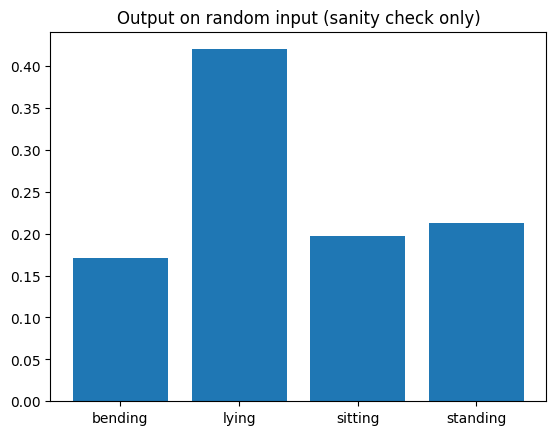

In [5]:
x = np.random.rand(1, 14739).astype("float32")
probs = pose_model.predict(x, verbose=0)[0]
print(dict(zip(labels, probs.round(3))))
print("Sum of probabilities:", probs.sum().round(3))

plt.bar(labels, probs)
plt.title("Output on random input (sanity check only)")
plt.show()

### Step 6 — Run the live demo
1. Open a terminal in the `pose/` folder.
2. Run: `python -m http.server 8000`
3. Open `http://localhost:8000` in Chrome, click **Start**, allow the camera.
4. Stand back so your whole body is visible. You will see the skeleton and 4 live probabilities.

Screenshot / screen-record this for the submission.

### Concepts
- **How it works:** Webcam frame → PoseNet (frozen, pre-trained) → 14,739-value feature vector → our Dense head → probabilities for bending / lying / sitting / standing.
- **Transfer Learning:** PoseNet is the pre-trained feature extractor; only the Dense head is trained. Same idea as Project A Task A6.2.
- **Why pose models are lighting-invariant:** they classify body-part positions, not pixel colours.
- **Limitation:** needs the full body in frame; a small training set means sensitivity to camera distance and angle.